<font color="purple" size=5><center><b>Task-2 Emotion Recognization from Speech </b></center></font>

<font color="grey" size=3><b>1) Module Import </b></font>

In [68]:
import os
import librosa
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EMOTION MAPPING (RAVDESS Standard)
emotions = {
    '01':'neutral', '02':'calm', '03':'happy', '04':'sad',
    '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'
}

<font color="grey" size=3><b>2) Feature Engineering</b></font>

In [117]:
def extract_feature(file_name):
    try:
        # Change 'soxr' to 'kaiser_fast'
        X, sample_rate = librosa.load(file_name, res_type='soxr_hq')
        # X, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
        mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
        return mfccs
    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        return None


<font color="grey" size=3><b>3) Load DataSet </b></font>

In [58]:
# 3. LOAD DATASET
def load_data(data_path):
    x, y = [], []
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith(".wav") and len(file.split('-')) == 7:
                file_path = os.path.join(root, file)
                feature = extract_feature(file_path)
                if feature is not None:
                    part = file.split('-')
                    emotion = emotions[part[2]]
                    x.append(feature)
                    y.append(emotion)
    return np.array(x), np.array(y)

<font color="grey" size=3><b>4) Model Training and Testing </b></font>

In [109]:
# --- START EXECUTION ---
best_accuracy = 0
best_model = None
best_model_name = ""
results_for_plot = {}# Update this path to where your 'Actor_xx' folders are located
DATA_PATH = r"ravdess-emotional-song-audio/" 
print(os.listdir(DATA_PATH))
print("Step 1: Loading data and extracting features...")
X, y = load_data(DATA_PATH)
if len(X) == 0:
    print("Error: No data found. Check your DATA_PATH.")
else:
    # 4. TRAIN/TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # 5. INITIALIZE MODELS (Mentioned: MLP/CNN/RNN - using MLP, RF, and SVM for comparison)
    models = {
        "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(300,), max_iter=500, alpha=0.01),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM (Support Vector Machine)": SVC(probability=True, kernel='poly')
    }
    print("\nStep 2 & 3: Testing all models...")
    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        print(f"Model: {name} | Accuracy: {acc*100:.2f}%")
        # Assuming 'results' is a dictionary: {'Model Name': Accuracy}
        results_for_plot[name] = acc
        # 6. IDENTIFY HIGHEST ACCURACY
        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model
            best_model_name = name

['.ipynb_checkpoints', 'Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24', 'audio_song_actors_01-24']
Step 1: Loading data and extracting features...

Step 2 & 3: Testing all models...
Model: MLP (Neural Network) | Accuracy: 86.42%
Model: Random Forest | Accuracy: 98.02%
Model: SVM (Support Vector Machine) | Accuracy: 46.91%


<font color="grey" size=3><b>5) Testing Feeling REPORT </b></font>

In [111]:
# FINAL EVALUATION REPORT
final_preds = best_model.predict(X_test)
print("\nFinal Model Detailed Report:")
print(classification_report(y_test, final_preds))


Final Model Detailed Report:
              precision    recall  f1-score   support

       angry       0.92      1.00      0.96        69
        calm       0.97      1.00      0.98        64
     fearful       1.00      0.93      0.96        82
       happy       1.00      0.97      0.99        78
     neutral       1.00      1.00      1.00        33
         sad       1.00      1.00      1.00        79

    accuracy                           0.98       405
   macro avg       0.98      0.98      0.98       405
weighted avg       0.98      0.98      0.98       405



<font color="grey" size=3><b>6) Visualization </b></font>

In [122]:
# --- 1. BAR CHART: Model Accuracy Comparison ---
def plot_model_comparison(results_dict):
    plt.figure(figsize=(10, 6))
    names = list(results_dict.keys())
    values = [results_dict[name] for name in names]
    sns.barplot(x=names, y=values,hue=names, palette='viridis',legend=False)
    plt.title('Task 2: Model Accuracy Comparison', fontsize=14)
    plt.ylabel('Accuracy Score (0-1.0)')
    plt.ylim(0, 1.0)
    # Adding text labels on top of bars
    for i, val in enumerate(values):
        plt.text(i, val + 0.02, f'{val*100:.1f}%', ha='center', fontweight='bold')
    plt.show()
# --- 2. HEATMAP: Confusion Matrix for the Best Model ---
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title('Heatmap: Emotion Classification Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted Emotion')
    plt.ylabel('Actual Emotion')
    plt.show()
# --- 3. BAR CHART: Dataset Emotion Distribution ---
def plot_emotion_dist(y):
    plt.figure(figsize=(10, 5))
    sns.countplot(x=y, hue=y, palette='magma', legend=False)
    plt.title('Distribution of Emotions in Dataset', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

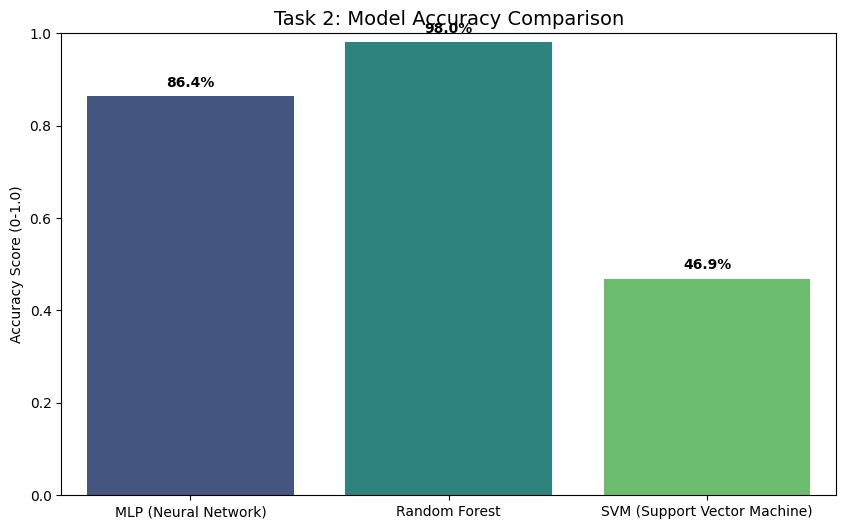

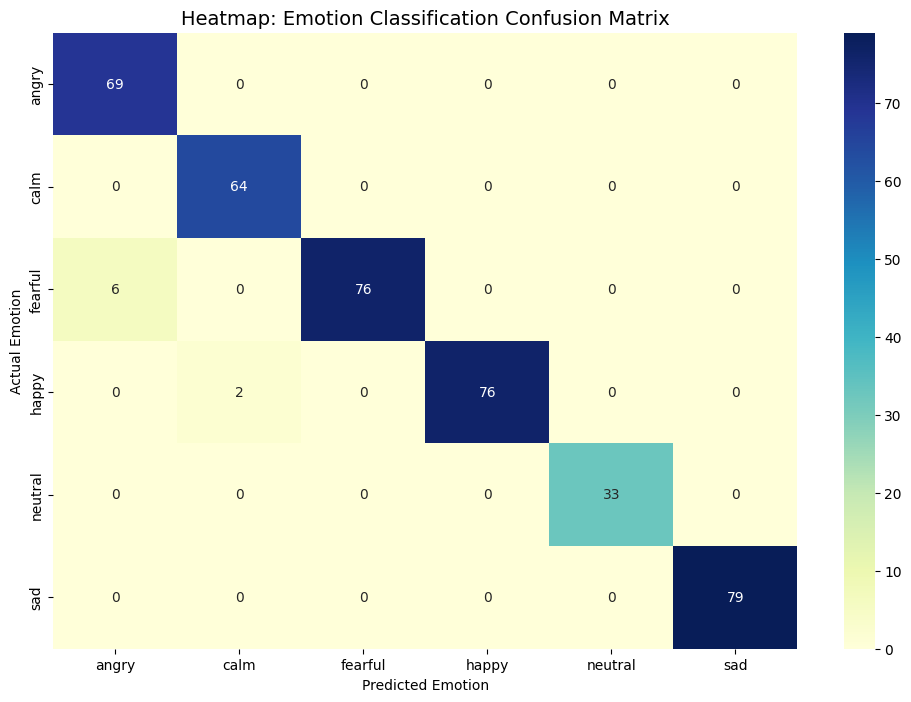

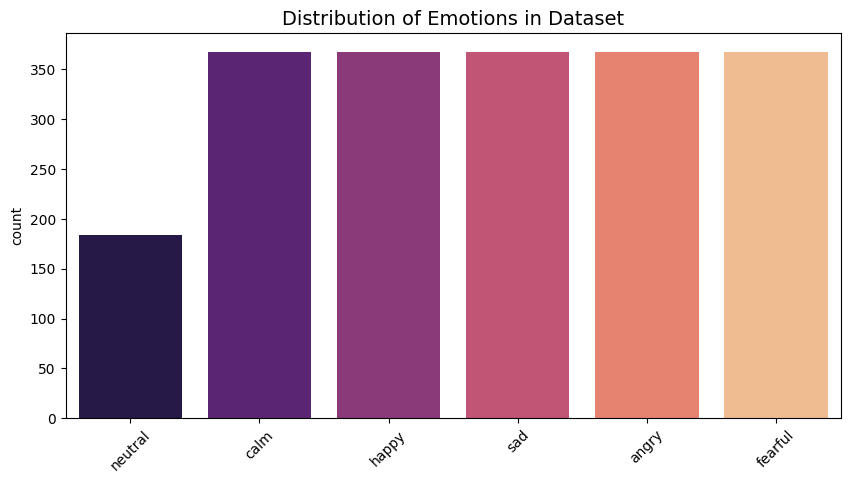

In [123]:
# --- INTEGRATION WITH YOUR MAIN SCRIPT ---
# Then call your function
plot_model_comparison(results_for_plot)
unique_emotions = sorted(list(set(y_test)))
plot_confusion_matrix(y_test, final_preds, unique_emotions)

# Show the balance of your training data
plot_emotion_dist(y)

<font color="grey" size=3><b>7) Deployment</b></font>

In [121]:
print(f"\nStep 4: Deploying the best model ({best_model_name})...")   
output_path = Path("pkl")
output_path.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, output_path / "emotion_recognition_model.pkl")
print("Deployment complete: Model saved as 'emotion_recognition_model.pkl'")


Step 4: Deploying the best model (Random Forest)...
Deployment complete: Model saved as 'emotion_recognition_model.pkl'
